# **Imports section**


In [ ]:
import torch
import torch.nn.functional as F
import json, os, random
from math import ceil
from tqdm.auto import tqdm
import numpy as np
from random import choice
from datasets import load_dataset, Dataset
from transformers import EarlyStoppingCallback
from sentence_transformers.sentence_transformer.evaluation import SentenceEvaluator
from sentence_transformers import (SentenceTransformer,
                                   SentenceTransformerTrainer,
                                   SentenceTransformerTrainingArguments,
                                   CrossEncoder,
                                   CrossEncoderTrainer,
                                   CrossEncoderTrainingArguments,
                                   losses)

/tmp/ipykernel_4728/346990491.py:11: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers import (SentenceTransformer,


# **Constants**

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# The seed is for reproducibility
random.seed(42)

Device: cuda


# **Data preprocessing**

In [ ]:
# Preparing triplets (anchor, positive, negative)
# This function is used to prepare the dataset to finetune the model with the standard
# sentence triplets strategy. In particular, we choose only one negative per query.
def prepare_triplet(data):
    negatives = [c for c in data["candidate_chunks"] if c != data["answer"]]
    neg = choice(negatives)
    return {
        "anchor": data["query"],
        "positive": data["answer"],
        "negative": neg
    }

ds = load_dataset("sapienzanlp-course-materials/hw-mnlp-2026")

# Splitting the given dataset in 90/10 train/dev
train_dev_split = ds['train'].train_test_split(test_size=0.1, seed=42)
ds_train = train_dev_split['train']
ds_dev = train_dev_split['test']
ds_test = ds['test']
ds_blind = ds['blind']

triplet_ds_train = ds_train.map(prepare_triplet, remove_columns=ds_train.column_names)
triplet_ds_dev = ds_dev.map(prepare_triplet, remove_columns=ds_dev.column_names)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/16.7M [00:00<?, ?B/s]

data/blind-00000-of-00001.parquet:   0%|          | 0.00/10.9M [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/66.6M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating blind split:   0%|          | 0/1322 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7200 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

# **Evaluation Metrics**

## **Helpers**

In [ ]:
# This function is used to perform a batch embedding of the dataset, very useful to
# precompute embedded dataset in order to improve the speed in the retrieving of the evaluation metrics
def embed_batch(batch, model, log_info, batch_size=64):
    """
    Embed a batch of examples using the given model. Done to improve encoding speed.
    """

    q_embs = model.encode(
        batch["query"],
        batch_size=batch_size,
        convert_to_tensor = True,
    )

    # Flattening consecutive candidate chunks to aggregate them in a single batch
    lengths = batch["n_candidates"]
    flat_candidates = []
    for cands in batch["candidate_chunks"]:
        for chunk in cands:
            flat_candidates.append(chunk)

    flat_cand_embs = model.encode(
        flat_candidates,
        batch_size=batch_size,
        convert_to_tensor = True,
    )

    loading_bar = log_info["loading_bar"]
    loading_bar.update(1)

    # Reshaping chunk embeddings in the original chunk group
    cand_embs = []
    start = 0
    for n in lengths:
        cand_embs.append(flat_cand_embs[start:start + n])
        start += n

    emb_batch = {
        "q_emb": q_embs,
        "query_id": batch["query_id"],
        "cand_embs": cand_embs,
    }

    # This condition is needed in the case of the blind set, which is not
    # provided of the answer. In this way we can reuse this function for both cases
    # (blind and test/train)
    if "answer_pos" in batch:
        emb_batch["answer_pos"] = batch["answer_pos"]

    return emb_batch

# This function wraps the usage of the `embed_batch` function in order to precompute
# the embedded dataset
def preprocess_data(model, dataset, split_name = None, batch_size = 64):
    """
    Prepare an embedded version of the dataset.
    """

    # In inference time is importat to activate evaluation mode of the model
    model.eval()
    with torch.no_grad():
        if split_name is not None:
            dataset = dataset[split_name]

        emb_dataset = []

        log_info = {}
        log_info["tot_batches"] = ceil(len(dataset) / batch_size)
        loading_bar = tqdm(total=log_info["tot_batches"], desc="Encoding")
        log_info["loading_bar"] = loading_bar

        # Slicing the dataset in batch and iteratively embed them with the helper `embed_batch`.
        # Note: this operation could also be implemented with dataset.map(embed_batch, ...).
        # However, using the model inside the function passed to map() gets stuck the execution of the cell,
        # so we process the dataset explicitly in batches instead.
        for i in range(0, len(dataset), batch_size):
            batch = dataset[i:i + batch_size]
            emb_batch = embed_batch(batch, model, log_info, batch_size)

            for j in range(len(emb_batch["q_emb"])):
                data = {
                    "q_emb": emb_batch["q_emb"][j],
                    "query_id": emb_batch["query_id"][j],
                    "cand_embs": emb_batch["cand_embs"][j],
                }

                # In order to reuse this functin for the blind set
                if split_name != "blind":
                    data["answer_pos"] = emb_batch["answer_pos"][j]

                emb_dataset.append(data)

        loading_bar.close()

    return emb_dataset

def get_ranks(emb_dataset):
    """
    Compute the ranks of the correct answers for all queries in the dataset.
    Returns a list of integers [r_1, ..., r_n], where r_i is the rank of the
    correct answer for query `i` after sorting its candidate chunks by similarity score and
    the similarity ladder, that are the ranked similarity scores for each query.
    """
    ranks = []
    sim_ladder = {}

    for data in emb_dataset:

        q_emb = data["q_emb"]
        cands_emb = data["cand_embs"]
        qid = data["query_id"]

        scores = F.cosine_similarity(q_emb, cands_emb)

        ranked_idx = torch.argsort(scores, descending=True).tolist()

        # The similarity ladder is used to produce the jsonl output files.
        sim_ladder[qid] = ranked_idx

        # In order to reuse this function for the blind set (which doesn't have
        # answer_pos)
        if "answer_pos" in data:
            answer_pos = data["answer_pos"]
            rank = ranked_idx.index(answer_pos)  + 1
            ranks.append(rank)

    return ranks, sim_ladder # ranks shape: [N], N number of queries

In [ ]:
# Helper to produce jsonl files
def produce_jsonl(sim_ladder, filename):
    path = os.path.join("outputs_file", filename)
    os.makedirs(os.path.dirname(path), exist_ok=True)

    with open(path, "w") as f:
        for query_id, chunk_ids in sim_ladder.items():
            row = {
                str(query_id): [int(chunk_id) for chunk_id in chunk_ids],
            }
            f.write(json.dumps(row) + "\n")

### **Hit@k**

Hit@k is a metric used to evaluate the accuracy of retrieval systems. It measures whether the correct answer is present among the top k chunks recommended by the system. If the relevant item (the *answer*) is found within the top k results, it's considered a **hit**.

The formula for Hit@k is:

$$Hit@k = \frac{1}{N} \sum_{i = 1}^{N} \mathbb{I}[rank_i \leq k]$$

where:
- $\mathbb{I}$ is the indicator function;
- $k$ is the size of the top ranked window within which the correct answer is considered a hit;
- $rank_i$ is the rank of the first relevant chunk for the $i$-th query.

In [ ]:
k_s = [1, 3, 5, 10]
def compute_hit_at_k(k, ranks):
    """
    Compute the Hit@k metric for a given value of k. It accepts the ranks returned by `get_ranks`.
    """
    hits = []

    for rank in ranks:
        hit = 1.0 if rank <= k else 0.0
        hits.append(hit)

    return float(np.mean(hits))

def compute_multiple_hit_at_k(k_s, ranks):
    """
    Compute multiple istances of Hit@k for different values of k.
    """
    values = {}

    for k in k_s:
        values[k] = compute_hit_at_k(k, ranks)

    return values


### **MRR**

This metric assesses the effectiveness of a information retrivial system by giving higher scores to systems that rank relevant items higher. It is calculated as the average of the reciprocal ranks of the answer for a set of queries.

The formula for MRR is:

$$MRR = \frac{1}{N} \sum_{i=1}^{N} \frac{1}{rank_i}$$

where:
- $N$ is the total number of queries.
- $rank_i$ is the rank of the first relevant chunk for the $i$-th query.

In [ ]:
def compute_mrr(ranks):
    """
    Very straightforward function. It implements the MRR metric by computing reciprocal ranks and
    performing the mean.
    """
    reciprocal_ranks = []

    for rank in ranks:
        rr = 1.0 / rank
        reciprocal_ranks.append(rr)

    return float(np.mean(reciprocal_ranks))

# **Baseline**

In [ ]:
# Loading of the baseline models: distilbert, minilm, mpnet (the latter is an additional one)
bert_baseline_model = SentenceTransformer("distilbert-base-uncased")
bert_baseline_model.to(device)

MiniLM_baseline_model = SentenceTransformer("all-MiniLM-L6-v2")
MiniLM_baseline_model.to(device)

mpnet_baseline_model = SentenceTransformer("all-mpnet-base-v2")
mpnet_baseline_model.to(device)

# Precomputing embeddings with the baseline models and getting free the gpu memory
bert_emb_dataset = preprocess_data(
    model = bert_baseline_model,
    dataset = ds,
    split_name = "test",
)

del bert_baseline_model
torch.cuda.empty_cache()

MiniLM_emb_dataset = preprocess_data(
    model = MiniLM_baseline_model,
    dataset = ds,
    split_name = "test",
)

del MiniLM_baseline_model
torch.cuda.empty_cache()

mpnet_emb_dataset = preprocess_data(
    model = mpnet_baseline_model,
    dataset = ds,
    split_name = "test",
)

del mpnet_baseline_model
torch.cuda.empty_cache()

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding:   0%|          | 0/31 [00:00<?, ?it/s]

Encoding:   0%|          | 0/31 [00:00<?, ?it/s]

Encoding:   0%|          | 0/31 [00:00<?, ?it/s]

In [ ]:
# Retrieving ranks (in this phase we don't need similarity ladder, which is instead used to produce jsonl files)
bert_ranks, _ = get_ranks(bert_emb_dataset)
MiniLM_ranks, _ = get_ranks(MiniLM_emb_dataset)
mpnet_ranks, _ = get_ranks(mpnet_emb_dataset)

# Compute MRR with the baseline models
bert_baseline_mrr = compute_mrr(
    ranks = bert_ranks,
)

MiniLM_baseline_mrr = compute_mrr(
    ranks = MiniLM_ranks,
)

mpnet_baseline_mrr = compute_mrr(
    ranks = mpnet_ranks,
)

# Compute hit@k with the baseline models
bert_baseline_hits_at_k = compute_multiple_hit_at_k(
    ranks = bert_ranks,
    k_s = k_s,
)

MiniLM_baseline_hits_at_k = compute_multiple_hit_at_k(
    ranks = MiniLM_ranks,
    k_s = k_s,
)

mpnet_baseline_hits_at_k = compute_multiple_hit_at_k(
    ranks = mpnet_ranks,
    k_s = k_s,
)

print("Baseline Model: distilbert-base-uncased")
print(f"Baseline MRR: {bert_baseline_mrr:.4f}")
print("Baseline Hit@k:")
print(
    f"k = 1: {bert_baseline_hits_at_k[1]:.4f} | "
    f"k = 3: {bert_baseline_hits_at_k[3]:.4f} | "
    f"k = 5: {bert_baseline_hits_at_k[5]:.4f}"
)

print("Baseline Model: all-MiniLM-L6-v2")
print(f"Baseline MRR: {MiniLM_baseline_mrr:.4f}")
print("Baseline Hit@k:")
print(
    f"k = 1: {MiniLM_baseline_hits_at_k[1]:.4f} | "
    f"k = 3: {MiniLM_baseline_hits_at_k[3]:.4f} | "
    f"k = 5: {MiniLM_baseline_hits_at_k[5]:.4f}"
)

print("Baseline Model: all-mpnet-base-v2")
print(f"Baseline MRR: {mpnet_baseline_mrr:.4f}")
print("Baseline Hit@k:")
print(
    f"k = 1: {mpnet_baseline_hits_at_k[1]:.4f} | "
    f"k = 3: {mpnet_baseline_hits_at_k[3]:.4f} | "
    f"k = 5: {mpnet_baseline_hits_at_k[5]:.4f}"
)

Baseline Model: distilbert-base-uncased
Baseline MRR: 0.3657
Baseline Hit@k:
k = 1: 0.1765 | k = 3: 0.4435 | k = 5: 0.6045
Baseline Model: all-MiniLM-L6-v2
Baseline MRR: 0.6093
Baseline Hit@k:
k = 1: 0.4480 | k = 3: 0.7165 | k = 5: 0.8080
Baseline Model: all-mpnet-base-v2
Baseline MRR: 0.6611
Baseline Hit@k:
k = 1: 0.5110 | k = 3: 0.7650 | k = 5: 0.8540


# **Evaluator**

The evaluator measures the performance of the finetuned model by computing:
- the $MRR$
- the $Hit@k$ with $k \in \{1, 3, 5\}$

In [ ]:
# The evaluator is used during the training phase to keep track of both evaluation metrics: MRR and Hit@k
class Evaluator(SentenceEvaluator):

    # The batch size is only to improve speed in encoding of chunks
    def __init__(self, dataset, name = None):
        self.dataset = dataset
        self.name = name

    def __call__(self, model, output_path=None, epoch: int = -1, steps: int = -1):

        # Preprocess embeddings inside the evaluator to use the current model
        emb_dataset = preprocess_data(
            model = model,
            dataset = self.dataset,
        )

        ranks, _ = get_ranks(emb_dataset)

        mrr = compute_mrr(
            ranks = ranks,
        )

        k_s = [1, 3, 5]
        hits_at_k = compute_multiple_hit_at_k(
            ranks = ranks,
            k_s = k_s,
        )

        metrics = {"eval_mrr": mrr}
        for k, hit_value in hits_at_k.items():
            metrics[f"eval_hit@{k}"] = hit_value

        return metrics

# **Sentence Triplets Finetuning**
The finetuning process using triplets involves training the `SentenceTransformer` model to embed sentences such that an 'anchor' (the `query`) sentence is similar in the embedding space to a 'positive' sentence (the `correct answer`) than it is to a 'negative' sentence (the `unrelated answer`). This is achieved through a `TripletLoss` function, which optimizes the model to maintain a certain margin between the anchor-positive and anchor-negative distances.

In [ ]:
# Instantiate the model
st_ft_model = SentenceTransformer("distilbert-base-uncased")
st_ft_model.to(device)

# Instantiate the evaluator
evaluator = Evaluator(ds_dev)

# Triplet loss for (anchor, positive, negative) samples
loss = losses.TripletLoss(
    model = st_ft_model,
    distance_metric = losses.TripletDistanceMetric.COSINE,
    triplet_margin = 0.25,
)

# Training arguments
training_args = SentenceTransformerTrainingArguments(
    output_dir = "weights/sentence_triplets",
    num_train_epochs = 5,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size = 16,
    learning_rate = 2e-5,
    weight_decay = 0.001,

    eval_strategy = "epoch",
    save_strategy = "epoch",
    logging_steps = 50,

    load_best_model_at_end=True,
    metric_for_best_model = "eval_mrr",
    greater_is_better = True,

    warmup_steps = 0.1
)

# Instantiate the trainer
# Notice that the optimizer is not explicitly chosen. By default, AdamW is used.
trainer = SentenceTransformerTrainer(model = st_ft_model,
                                     args = training_args,
                                     train_dataset = triplet_ds_train,
                                     eval_dataset = triplet_ds_dev,
                                     evaluator = evaluator,
                                     loss = loss,
                                     callbacks = [EarlyStoppingCallback(early_stopping_patience=2)]
                                     # Early stopping callback stops the execution if the choosen metric
                                     # doesn't improve after `early_stopping_patience` evaluation steps
                                     # (defined in the `eval_strategy` field).
                                     )
trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Epoch,Training Loss,Validation Loss,Mrr,Hit@1,Hit@3,Hit@5
1,0.074529,0.070054,0.664289,0.521250,0.771250,0.845000
2,0.050038,0.061329,0.697787,0.570000,0.778750,0.876250
3,0.035046,0.059524,0.697504,0.570000,0.783750,0.878750
4,0.027125,0.057489,0.699570,0.568750,0.785000,0.885000
5,0.020153,0.057708,0.700544,0.571250,0.783750,0.885000


Encoding:   0%|          | 0/12 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding:   0%|          | 0/12 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

TrainOutput(global_step=1125, training_loss=0.05064272091123793, metrics={'train_runtime': 2728.8454, 'train_samples_per_second': 13.192, 'train_steps_per_second': 0.412, 'total_flos': 0.0, 'train_loss': 0.05064272091123793, 'epoch': 5.0})

In [ ]:
# Here we are computing the embedded dataset with the `st_ft_model`, to retrieve ranks, metrics and to produce jsonl output files
# for both test and blind dataset. This is the first time that this model processes the test set.
st_test_emb_dataset = preprocess_data(
    model = st_ft_model,
    dataset = ds,
    split_name = "test"
)

st_blind_emb_dataset = preprocess_data(
    model = st_ft_model,
    dataset = ds,
    split_name = "blind",
)

Encoding:   0%|          | 0/31 [00:00<?, ?it/s]

Encoding:   0%|          | 0/20 [00:00<?, ?it/s]

In [ ]:
# Retrieving the ranks and similarity ladders for both test and blind set
# Notice that ranks of blind set are not availables because the dataset is not
# answers provided
st_test_ranks, st_test_sim_ladder = get_ranks(st_test_emb_dataset)
_, st_blind_sim_ladder = get_ranks(st_blind_emb_dataset)

st_mrr = compute_mrr(
    ranks = st_test_ranks,
)

st_hits_at_k = compute_multiple_hit_at_k(
    ranks = st_test_ranks,
    k_s = k_s,
)

# Logging phase
print("Finetuned Model: distilbert-base-uncased finetuned with sentence triplets")
print(f"Finetuned Model MRR: {st_mrr:.4f}")
print("Finetuned Model Hit@k:")
print(
    f"k = 1: {st_hits_at_k[1]:.4f} | "
    f"k = 3: {st_hits_at_k[3]:.4f} | "
    f"k = 5: {st_hits_at_k[5]:.4f} | "
    f"k = 10: {st_hits_at_k[10]:.4f} "
)

produce_jsonl(st_test_sim_ladder, "TheOverfitters-test-distilbert_base_uncased-sentence_triplets.jsonl")
produce_jsonl(st_blind_sim_ladder, "TheOverfitters-blind-distilbert_base_uncased-sentence_triplets.jsonl")

del st_ft_model
torch.cuda.empty_cache()

Finetuned Model: distilbert-base-uncased finetuned with sentence triplets
Finetuned Model MRR: 0.7045
Finetuned Model Hit@k:
k = 1: 0.5755 | k = 3: 0.7985 | k = 5: 0.8745 | k = 10: 0.9455 


# **Hard Negatives Finetuning**


In [ ]:
# Preparing the dataset for the Hard Negatives setup. In this scenario, the we choose the hard negatives
# picking the first two chunks with the highest similarity score, based on the first retrivial step performed
# by the minlm baseline model.
def prepare_dataset(ds, sim_ladder, k=5):
    dataset = []

    for data in ds:
        qid = data["query_id"]
        answer_pos = int(data["answer_pos"])

        hard_neg = [
            data["candidate_chunks"][i]
            for i in sim_ladder[qid][:k]
            if i != answer_pos
        ]

        # Each element of the dataset has an anchor, a positive and two hard negatives
        item = {
            "anchor": data["query"],
            "positive": data["answer"],
        }

        for i, hneg in enumerate(hard_neg):
            item[f"negative_{i}"] = hneg


        dataset.append(item)

    return Dataset.from_list(dataset)

In [ ]:
# Loading the baseline model to produce the topk chunks in order to sample the hard negatives
MiniLM_baseline_model = SentenceTransformer("all-MiniLM-L6-v2")
MiniLM_baseline_model.to(device)

# Precomputing the embedded version of both train and dev sets
hard_neg_train_emb_dataset = preprocess_data(
    model = MiniLM_baseline_model,
    dataset = ds_train,
)

hard_neg_dev_emb_dataset = preprocess_data(
    model = MiniLM_baseline_model,
    dataset = ds_dev,
)

del MiniLM_baseline_model

_, hard_neg_train_sim_ladder = get_ranks(hard_neg_train_emb_dataset)
_, hard_neg_dev_sim_ladder = get_ranks(hard_neg_dev_emb_dataset)

# Preparing the dataset
HN_triplet_ds_train = prepare_dataset(ds_train, hard_neg_train_sim_ladder)
HN_triplet_ds_dev = prepare_dataset(ds_dev, hard_neg_dev_sim_ladder)

# Instantiate the model
HN_ft_model = SentenceTransformer("distilbert-base-uncased")
HN_ft_model.to(device)

# Instantiate the evaluator
evaluator = Evaluator(ds_dev)

torch.cuda.empty_cache()


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

## **MultipleNegativeRankingLoss**
As suggested in the documentation, MNRL is well suited to this scenario. In particular, it allows us to use `hardness_mode = "hard_negatives"`, so that hard negatives are weighted differently from the in batch negatives by tuning the `hardness_strength` parameter.
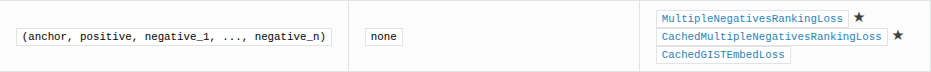

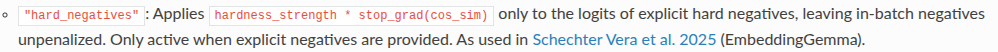

In [ ]:
# As suggested in the documentation, the loss for this setup is the MultipleNegativeRankingLoss.
loss = losses.MultipleNegativesRankingLoss(
    model = HN_ft_model,
    hardness_mode = "hard_negatives",
    hardness_strength = 0.1,
)

In [ ]:
# Training arguments
training_args = SentenceTransformerTrainingArguments(
    output_dir = "weights/Hard_negatives",
    num_train_epochs = 3,
    per_device_train_batch_size = 16,
    per_device_eval_batch_size = 16,
    learning_rate = 2e-5,
    weight_decay = 0.001,

    eval_strategy = "epoch",
    save_strategy = "epoch",
    logging_steps = 50,

    load_best_model_at_end=True,
    metric_for_best_model = "eval_mrr",
    greater_is_better = True,

    warmup_steps = 0.1
)

# Instantiate the trainer
# Notice that the optimizer is not explicitly chosen. By default, AdamW is used.
trainer = SentenceTransformerTrainer(model = HN_ft_model,
                                     args = training_args,
                                     train_dataset = HN_triplet_ds_train,
                                     eval_dataset = HN_triplet_ds_dev,
                                     evaluator = evaluator,
                                     loss = loss,
                                     callbacks = [EarlyStoppingCallback(early_stopping_patience=2)]
                                     # Early stopping callback stops the execution if the choosen metric
                                     # doesn't improve after `early_stopping_patience` evaluation steps
                                     # (defined in the `eval_strategy` field).
                                     )
# Launching the training
trainer.train()

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Epoch,Training Loss,Validation Loss,Mrr,Hit@1,Hit@3,Hit@5
1,1.047037,1.026895,0.684472,0.545000,0.792500,0.876250
2,0.742325,0.950701,0.710924,0.583750,0.802500,0.885000
3,0.596281,0.951268,0.712803,0.588750,0.808750,0.880000


Encoding:   0%|          | 0/13 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding:   0%|          | 0/13 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Encoding:   0%|          | 0/13 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

TrainOutput(global_step=1350, training_loss=0.897993216337981, metrics={'train_runtime': 1938.0196, 'train_samples_per_second': 11.145, 'train_steps_per_second': 0.697, 'total_flos': 0.0, 'train_loss': 0.897993216337981, 'epoch': 3.0})

# **Evaluation**

In [ ]:
HN_test_emb_dataset = preprocess_data(
    model = HN_ft_model,
    dataset = ds,
    split_name = "test"
)

HN_blind_emb_dataset = preprocess_data(
    model = HN_ft_model,
    dataset = ds,
    split_name = "blind",
)

Encoding:   0%|          | 0/32 [00:00<?, ?it/s]

Encoding:   0%|          | 0/21 [00:00<?, ?it/s]

In [ ]:
HN_test_ranks, HN_test_sim_ladder = get_ranks(HN_test_emb_dataset)
_, HN_blind_sim_ladder = get_ranks(HN_blind_emb_dataset)

HN_st_mrr = compute_mrr(
    ranks = HN_test_ranks,
)

HN_st_hits_at_k = compute_multiple_hit_at_k(
    ranks = HN_test_ranks,
    k_s = k_s,
)

print("Finetuned Model: distilbert-base-uncased finetuned with HN")
print(f"Finetuned Model MRR: {HN_st_mrr:.4f}")
print("Finetuned Model Hit@k:")
print(
    f"k = 1: {HN_st_hits_at_k[1]:.4f} | "
    f"k = 3: {HN_st_hits_at_k[3]:.4f} | "
    f"k = 5: {HN_st_hits_at_k[5]:.4f} | "
    f"k = 10: {HN_st_hits_at_k[10]:.4f} "
)

produce_jsonl(HN_test_sim_ladder, "TheOverfitters-test-distilbert_base_uncased-hard_negatives.jsonl")
produce_jsonl(HN_blind_sim_ladder, "TheOverfitters-blind-distilbert_base_uncased-hard_negatives.jsonl")

Finetuned Model: distilbert-base-uncased finetuned with HN
Finetuned Model MRR: 0.7062
Finetuned Model Hit@k:
k = 1: 0.5670 | k = 3: 0.8105 | k = 5: 0.8970 | k = 10: 0.9610 


# **Reranking stage**

In [ ]:
# Retrieving topk candidate chunks
def retrieve_top_k(sim_ladder, k, ds):
    """
    output shape:

        [{
          "query_id": query_id,
          "query": query,
          "topk_chunk_ids": [chunk_id0, chunk_id1, ...],
          "candidate_chunks": [chunk0, chunk1, ...],
        }, {...}, ...]
    """
    topk = []

    id_to_item = {item["query_id"]: item for item in ds}

    # We are going to create a topk item as specified in the function description
    for query_id, chunk_ids in sim_ladder.items():
        topk_chunks_id = chunk_ids[:k]
        topk_chunks = []
        item = id_to_item[query_id]
        for chunk_id in topk_chunks_id:
            topk_chunks.append(
                item["candidate_chunks"][chunk_id]
            )

        data = {
            "query_id": query_id,
            "query": id_to_item[query_id]["query"],
            "topk_chunk_ids": topk_chunks_id,
            "candidate_chunks": topk_chunks,
        }

        if item["answer_pos"] in topk_chunks_id:
            data["answer_pos"] = item["answer_pos"]

        topk.append(data)

    return topk

def build_topk_dataset(topk):
    dataset = []

    for item in topk:
        if "answer_pos" not in item:
            continue

        answer_pos = item["answer_pos"]
        topk_ids = item["topk_chunk_ids"]

        if answer_pos not in topk_ids:
            continue

        local_pos = topk_ids.index(answer_pos)
        answer = item["candidate_chunks"][local_pos]

        negatives = [
            c for i, c in enumerate(item["candidate_chunks"])
            if i != local_pos
        ]

        dataset.append({
            "query": item["query"],
            "chunk": answer,
            "label": 1,
        })

        for neg in random.sample(negatives, min(3, len(negatives))):
            dataset.append({
                "query": item["query"],
                "chunk": neg,
                "label": 0,
            })

    return Dataset.from_list(dataset)


def rerank(reranker, topk):

    reranked_ladder = {}

    for item in topk:
        qnas = []
        query = item["query"]
        qid = item["query_id"]
        for chunk in item["candidate_chunks"]:
            qna = (query, chunk)
            qnas.append(qna)
        scores = torch.tensor(reranker.predict(qnas))
        ranked_idx = torch.argsort(scores, descending = True).tolist()
        reranked_ladder[qid] = [
            item["topk_chunk_ids"][i] for i in ranked_idx
        ]

    return reranked_ladder

# **Finetuning CrossEncoder**

In [ ]:
k = 5

HN_ds_emb_train = preprocess_data(HN_ft_model, ds_train)
HN_ds_emb_dev = preprocess_data(HN_ft_model, ds_dev)

_, HN_train_sim_ladder = get_ranks(HN_ds_emb_train)
_, HN_dev_sim_ladder = get_ranks(HN_ds_emb_dev)

HN_train_topk = retrieve_top_k(HN_train_sim_ladder, k, ds_train)
HN_dev_topk = retrieve_top_k(HN_dev_sim_ladder, k, ds_dev)

HN_CE_train_ds = build_topk_dataset(HN_train_topk)
HN_CE_dev_ds = build_topk_dataset(HN_dev_topk)

Encoding:   0%|          | 0/113 [00:00<?, ?it/s]

Encoding:   0%|          | 0/13 [00:00<?, ?it/s]

In [ ]:
reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L12-v2", num_labels=1)

ce_training_args = CrossEncoderTrainingArguments(
    output_dir="/content/crossencoder",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
)

trainer = CrossEncoderTrainer(
    model=reranker,
    args=ce_training_args,
    train_dataset=HN_CE_train_ds,
    eval_dataset=HN_CE_dev_ds,
)

trainer.train()

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L12-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch,Training Loss,Validation Loss
1,0.320786,0.313609
2,0.271048,0.323538


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=4546, training_loss=0.3142304907168159, metrics={'train_runtime': 1487.6222, 'train_samples_per_second': 48.877, 'train_steps_per_second': 3.056, 'total_flos': 0.0, 'train_loss': 0.3142304907168159, 'epoch': 2.0})

In [ ]:
HN_test_topk = retrieve_top_k(HN_test_sim_ladder, k, ds_test)

HN_blind_topk = retrieve_top_k(HN_blind_sim_ladder, k, ds_blind)

HN_test_reranked_ladder = rerank(reranker, HN_test_topk)

HN_blind_reranked_ladder = rerank(reranker, HN_blind_topk)

In [ ]:
def merge_ladders(ladder, reranked_ladder, k):

      right_parts = {
          qid: chunk_ids[k:] for qid, chunk_ids in ladder.items()
      }

      merged_ladder = {
          qid: reranked_ladder[qid] + right_parts[qid] for qid in reranked_ladder
      }

      return merged_ladder

def get_rank_from_reranked(merged_reranked_ladder, ds):

    id_to_item = {item["query_id"]: item for item in ds}
    ranks = []

    for qid, chunk_ids in merged_reranked_ladder.items():
        item = id_to_item[qid]
        correct_pos = int(item["answer_pos"])

        rank = chunk_ids.index(correct_pos) + 1
        ranks.append(rank)

    return ranks

In [ ]:
HN_test_final_reranked_ladder = merge_ladders(HN_test_sim_ladder, HN_test_reranked_ladder, k)

HN_blind_final_reranked_ladder = merge_ladders(HN_blind_sim_ladder, HN_blind_reranked_ladder, k)

HN_final_ranks = get_rank_from_reranked(HN_test_final_reranked_ladder, ds_test)

produce_jsonl(HN_test_final_reranked_ladder, "TheOverfitters-test-distilbert_base_uncased-hard_negatives_RERANKED_top5.jsonl")
produce_jsonl(HN_blind_final_reranked_ladder, "TheOverfitters-blind-distilbert_base_uncased-hard_negatives_RERANKED_top5.jsonl")


HN_reranked_mrr = compute_mrr(ranks = HN_final_ranks)
HN_reranked_hits_at_k = compute_multiple_hit_at_k(
    ranks = HN_final_ranks,
    k_s = k_s,
)

print("Reranked stage: reranker --> ms-marco-MiniLM-L12-v2")
print(f"Reranked MRR: {HN_reranked_mrr}")
print("Reranker Hit@k:")
print(
    f"k = 1: {HN_reranked_hits_at_k[1]:.4f} | "
    f"k = 3: {HN_reranked_hits_at_k[3]:.4f} | "
    f"k = 5: {HN_reranked_hits_at_k[5]:.4f} | "
    f"k = 10: {HN_reranked_hits_at_k[10]:.4f} "
)

Reranked stage: ms-marco-MiniLM-L12-v2
Reranker Hit@k:
k = 1: 0.7030 | k = 3: 0.8685 | k = 5: 0.8970 | k = 10: 0.9610 
